[speed] mixed_float16 policy enabled
[speed] XLA JIT enabled
[speed] TF32 enabled (if supported)


Epoch 1/10: 100%|██████████| 234/234 [08:20<00:00,  2.14s/it]


Epoch 1: D=1.073 G=0.790 | 500.4s


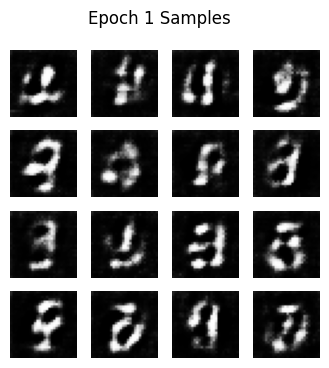

Epoch 2/10:  35%|███▌      | 82/234 [02:49<05:07,  2.03s/it]

In [ ]:
# ======================================================
# Lightweight DCGAN on MNIST
# ======================================================

import os, time
import numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision
from tqdm import tqdm
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
from tensorflow.keras import layers
from IPython.display import Audio, display

# Load & normalize MNIST
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = np.expand_dims(x_train, -1)
BATCH_SIZE, Z_DIM, EPOCHS = 128, 100, 10

dataset = (tf.data.Dataset.from_tensor_slices(x_train)
           .shuffle(60000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

# ---------- Models ----------
def make_generator():
    z = layers.Input(shape=(Z_DIM,))
    x = layers.Dense(7*7*128, use_bias=False)(z)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((7,7,128))(x)
    x = layers.Conv2DTranspose(64, 5, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2DTranspose(1, 5, strides=2, padding="same", activation="tanh")(x)
    return tf.keras.Model(z, x, name="Generator")

def make_discriminator():
    x_in = layers.Input(shape=(28,28,1))
    x = layers.Conv2D(64, 5, strides=2, padding="same")(x_in)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(128, 5, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(1)(x)
    return tf.keras.Model(x_in, x, name="Discriminator")

G, D = make_generator(), make_discriminator()
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
gopt = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
dopt = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

# -------- 1) System-wide speed knobs --------
# a) Mixed precision (automatic loss scaling will be used with Adam)
try:
    mixed_precision.set_global_policy("mixed_float16")
    print("[speed] mixed_float16 policy enabled")
except Exception as e:
    print(f"[speed:mixed] {e}")

# b) XLA JIT for tf.function
try:
    tf.config.optimizer.set_jit(True)
    print("[speed] XLA JIT enabled")
except Exception as e:
    print(f"[speed:xla] {e}")

# c) TF32 where supported (Ampere+); safe no-op otherwise
try:
    tf.config.experimental.enable_tensor_float_32_execution(True)
    print("[speed] TF32 enabled (if supported)")
except Exception as e:
    print(f"[speed:tf32] {e}")

# -------- 2) Hyperparams tuned for throughput --------
BATCH_SIZE = 256           # try 256/512 on GPU; if OOM, drop to 128
Z_DIM      = 100
EPOCHS     = 10
DEV_STEPS_PER_EPOCH = None # e.g., 200 for quick tests; None = full

# Recreate optimizers AFTER setting mixed precision policy
bce  = tf.keras.losses.BinaryCrossentropy(from_logits=True)
gopt = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
dopt = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

# -------- 3) Dataset pipeline (cache → shuffle → batch → prefetch) --------
# (Reuses already-normalized x_train in [-1,1] with shape (N,28,28,1))
AUTOTUNE = tf.data.AUTOTUNE
ds = tf.data.Dataset.from_tensor_slices(x_train)

# Version-safe options
opt = tf.data.Options()
# Throughput over determinism for training
if hasattr(opt, "experimental_deterministic"):
    opt.experimental_deterministic = False
exp_opt = getattr(opt, "experimental_optimization", None)
if exp_opt is not None:
    for attr in ["apply_default_optimizations","autotune","map_and_batch_fusion","map_fusion","parallel_batch"]:
        if hasattr(exp_opt, attr):
            setattr(exp_opt, attr, True)

dataset = (ds.cache()
             .shuffle(60000)
             .batch(BATCH_SIZE, drop_remainder=True)  # stable shapes help XLA
             .prefetch(AUTOTUNE)
             .with_options(opt))

# -------- 4) Training step (XLA-compiled) --------
@tf.function(experimental_compile=True)  # let XLA fuse kernels
def train_step(real):
    bs = tf.shape(real)[0]
    z  = tf.random.normal((bs, Z_DIM))

    # ----- Discriminator -----
    with tf.GradientTape() as td:
        fake = G(z, training=True)
        logits_real = D(real, training=True)
        logits_fake = D(fake, training=True)
        d_loss = bce(tf.ones_like(logits_real), logits_real) + \
                 bce(tf.zeros_like(logits_fake), logits_fake)
    grads_d = td.gradient(d_loss, D.trainable_variables)
    dopt.apply_gradients(zip(grads_d, D.trainable_variables))

    # ----- Generator (non-saturating) -----
    z = tf.random.normal((bs, Z_DIM))
    with tf.GradientTape() as tg:
        fake = G(z, training=True)
        logits_fake = D(fake, training=True)
        g_loss = bce(tf.ones_like(logits_fake), logits_fake)
    grads_g = tg.gradient(g_loss, G.trainable_variables)
    gopt.apply_gradients(zip(grads_g, G.trainable_variables))

    # Cast losses to float32 for logging under mixed precision
    return tf.cast(d_loss, tf.float32), tf.cast(g_loss, tf.float32)

# -------- 5) Training loop --------
FIXED_Z = tf.random.normal((16, Z_DIM))
card = tf.data.experimental.cardinality(dataset).numpy()
known_total = (card >= 0)
total_batches = min(card, DEV_STEPS_PER_EPOCH) if (known_total and DEV_STEPS_PER_EPOCH) else (card if known_total else None)

d_hist, g_hist = [], []
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    dL, gL = [], []

    # Lower tqdm frequency reduces Python/UI overhead
    step_counter = 0
    for real in tqdm(dataset, total=total_batches, desc=f"Epoch {epoch}/{EPOCHS}", mininterval=1.0):
        dl, gl = train_step(real)
        dL.append(float(dl)); gL.append(float(gl))
        step_counter += 1
        if DEV_STEPS_PER_EPOCH is not None and step_counter >= DEV_STEPS_PER_EPOCH:
            break

    d_mean, g_mean = float(np.mean(dL)), float(np.mean(gL))
    d_hist.append(d_mean); g_hist.append(g_mean)
    print(f"Epoch {epoch}: D={d_mean:.3f} G={g_mean:.3f} | {time.time()-t0:.1f}s")

    # Preview every few epochs only (plotting is slow)
    if epoch % 2 == 0 or epoch == 1:
        samples = G(FIXED_Z, training=False).numpy()
        samples = (samples + 1) / 2.0
        fig, axs = plt.subplots(4,4, figsize=(4,4))
        for i, ax in enumerate(axs.flat):
            ax.imshow(samples[i,...,0], cmap="gray"); ax.axis("off")
        plt.suptitle(f"Epoch {epoch} Samples"); plt.show(); plt.close()

# Final loss plot
plt.figure()
plt.plot(d_hist, label="D"); plt.plot(g_hist, label="G")
plt.title("GAN Losses"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.show(); plt.close()


# Mini DCGAN on MNIST — A Deep-Dive, College-Level Explanation

This note explains **what you just ran** (a lightweight DCGAN on MNIST), **why it works**, and **how to reason about its math, engineering trade-offs, and diagnostics**. It also includes **extensions** and **discussion prompts** suitable for a homework or lab.

---

## 1) Problem Setup & Data

- **Task.** Learn a generator $ G $ that maps a latent noise vector $ z \sim \mathcal{N}(0, I) $ to an image $ x = G(z) \in \mathbb{R}^{28\times 28} $, whose distribution $ p_G $ **resembles** the MNIST data distribution $ p_{\text{data}} $.
- **Data.** MNIST consists of $ 60{,}000 $ training images of handwritten digits (28×28 grayscale). We normalize pixel intensities to **$[-1, 1]$** so that the generator’s final **tanh** layer has a target range with non-saturating gradients around 0.

**Why MNIST?** It is:
- Small, so training converges in minutes,
- Diverse enough to show **mode coverage** vs **mode collapse**,
- Simple enough to debug training dynamics (loss curves, sample grids).

---

## 2) Model Architecture (DCGAN Pattern)

### 2.1 Generator $ G $
**Input.** $ z \in \mathbb{R}^{d} $ (e.g., $ d=100 $) sampled i.i.d. from a standard normal.

**Network.**
1. Dense layer to project $ z $ into a low-resolution spatial tensor (e.g., 7×7×128).
2. Upsampling via **Conv2DTranspose** (a.k.a. “deconvolution”) to 14×14 and then 28×28.
3. **Batch Normalization** + **LeakyReLU/ReLU** activations to stabilize and accelerate training.
4. Final **tanh** activation to bound output in $[-1,1]$.

**Intuition.** The generator learns a **procedural mapping** that “paints” digit-like strokes from a random seed, progressively refining coarse structure to finer details.

### 2.2 Discriminator $ D $
**Input.** Real or generated images $ x \in \mathbb{R}^{28\times 28 \times 1} $.

**Network.**
1. A short **Conv → LeakyReLU** stack, downsampling to a compact representation.
2. Final **dense** layer to a single **logit** (real/fake evidence before sigmoid).

**Intuition.** The discriminator acts as a learned **energy function** (or a flexible classifier) that assigns higher scores to images that look “realistic” under the training distribution and lower scores to those that look synthetic.

---

## 3) Objectives & Training Dynamics

### 3.1 Non-Saturating GAN Loss (Standard DCGAN)

We use **Binary Cross-Entropy (BCE)** with logits:

- **Discriminator loss** (maximize likelihood of correct labels; equivalently minimize BCE):
$$
\mathcal{L}_D
= \mathbb{E}_{x \sim p_{\text{data}}}\left[\,\text{BCE}(1, D(x))\,\right]
+ \mathbb{E}_{z \sim p(z)}\left[\,\text{BCE}(0, D(G(z)))\,\right].
$$

- **Generator loss** (non-saturating form to avoid vanishing gradient when $ D $ is strong):
$$
\mathcal{L}_G
= \mathbb{E}_{z \sim p(z)}\left[\,\text{BCE}(1, D(G(z)))\,\right].
$$

**Why “non-saturating”?** The original minimax generator loss $ \mathbb{E}[\log (1 - D(G(z)))] $ can saturate when $ D(G(z))\approx 0 $. Using $ \text{BCE}(1,D(G(z))) $ maintains **strong gradients** and speeds convergence.

### 3.2 Minimax Game Intuition

- The discriminator $ D $ seeks a decision boundary that separates real samples from generated ones.
- The generator $ G $ evolves to produce samples that fool $ D $, pushing $ p_G $ closer to $ p_{\text{data}} $.
- **Equilibrium:** If $ p_G = p_{\text{data}} $, then the optimal discriminator outputs $ D(x) = 1/2 $ for all $ x $ — the game is **indifferent**, and both losses plateau.

---

## 4) Engineering Choices & “Why”

### 4.1 Normalization and Activations
- **Generator:** BatchNorm + (Leaky)ReLU helps stabilize hidden statistics; **tanh** constrains outputs.
- **Discriminator:** LeakyReLU is standard to maintain gradient flow for negative inputs; no batch norm in the last layer (logit).

### 4.2 Optimizer & Hyperparameters
- **Adam** with $ \beta_1=0.5 $ (DCGAN default) reduces momentum overshoot and improves stability in adversarial training.
- **Learning rate** $ 1\mathrm{e}{-4} $ balances speed and stability.
- **Latent dimension $ Z\_DIM $**: 100 is a common sweet spot for diversity vs. learnability.

### 4.3 Throughput Optimizations (Colab)
- **Mixed Precision (FP16)** on GPU: doubles math throughput in many convs and reduces memory bandwidth.
- **XLA (JIT)**: compiles the `@tf.function` training step into fused kernels, reducing Python overhead.
- **Larger batches** (e.g., 256) if memory allows (more parallelism).
- **tf.data pipeline**: `cache → shuffle → batch(drop_remainder=True) → prefetch` keeps the GPU fed.

---

## 5) Diagnostics & Interpreting Curves

### 5.1 Loss Curves
- **$ \mathcal{L}_D $ too low, $ \mathcal{L}_G $ high**: Discriminator is overpowering. Try lowering D capacity slightly, adding label smoothing/noise, or training G more steps per iteration.
- **$ \mathcal{L}_D $ high, $ \mathcal{L}_G $ low**: Generator may be overpowering (rare early on). Increase D capacity or training steps; check for data pipeline bugs.
- **Both losses oscillate moderately**: Normal in GANs; monitor **sample quality** rather than expecting monotone convergence.

### 5.2 Visual Samples
- **Early epochs**: Blobby grayscale patterns (good sign: structure emerges quickly).
- **Mid training**: Legible digits with occasional artifacts; **diversity** across classes is important.
- **Failure modes**:
  - **Mode collapse**: The generator produces highly similar digits regardless of $ z $. Remedies: increase $ n\_\text{critic} $ (more D steps per G step), add noise to D inputs, try **WGAN-GP** objective, or modify architecture slightly.
  - **Checkerboard artifacts**: Sometimes from Conv2DTranspose. Remedies: replace with upsampling + Conv2D, or use kernel sizes/strides that tile perfectly.

---

## 6) Mathematical Deepening (Compact)

### 6.1 Optimal Discriminator (for fixed $ G $)
For binary real/fake classification with BCE, the optimal $ D $ satisfies:
$$
D^*(x) \;=\; \frac{p_{\text{data}}(x)}{p_{\text{data}}(x) + p_G(x)}.
$$
At $ p_G = p_{\text{data}} $, $ D^*(x)=\tfrac{1}{2} $ and $ G $ receives very small gradient signals—**equilibrium**.

### 6.2 Divergence Minimization View
Under the original minimax loss, GANs approximately minimize the **Jensen–Shannon divergence** between $ p_{\text{data}} $ and $ p_G $. Alternative objectives (e.g., **Wasserstein** with gradient penalty) change the geometry and often improve stability.

---

## 7) Reproducibility, Fairness, and Ethics

- **Reproducibility:** Fix random seeds; record library versions; remember that parallelism and mixed precision introduce small nondeterminisms.
- **Fairness & Misuse:** Even simple GANs can be co-opted for **deepfake-style** tasks with upscaling. Always contextualize the educational intent and potential risks; avoid training on sensitive identities or biased corpora.

---

## 8) Suggested Experiments (Student-Friendly)

1. **Latent Traversals.** Fix all but one latent dimension $ z_i $; vary $ z_i $ in small increments and visualize how the digit morphs.  
   *Question:* Which dimensions correlate with **stroke thickness**, **slant**, or **class**?

2. **Conditional GAN (cGAN).** Concatenate a **one-hot digit label** to $ z $ (and to intermediate discriminator features) to control the generated class.  
   *Question:* How does conditioning affect mode coverage and training speed?

3. **Fashion-MNIST Swap.** Replace MNIST with **Fashion-MNIST** (same shape).  
   *Question:* Does training take longer? Are artifacts different? Why?

4. **Hinge Loss vs BCE.** Replace BCE with **hinge loss** for $ D $ and $ G $.  
   *Question:* Compare stability and sample quality.

5. **UpSampling+Conv2D vs Conv2DTranspose.**  
   *Question:* Do checkerboard artifacts change? Which variant converges faster?

---

## 9) Practical “Knobs” Cheat Sheet

- **Batch size:** ↑ batch → ↑ throughput (until OOM).  
- **Learning rates:** $ 1\mathrm{e}{-4} $ is stable; try $ 2\mathrm{e}{-4} $ if learning stalls.  
- **$\beta_1$:** $ 0.5 $ is a good DCGAN default; try $ 0.0 $–$ 0.9 $ to see momentum effects.  
- **Label smoothing/noise:** e.g., real labels $ \in [0.8, 1.0] $, add small Gaussian noise to inputs—**regularizes** $ D $.  
- **n\_critic (D steps per G step):** try 2–5 in tricky regimes; helps $ D $ track new generator modes.

---

## 10) Evaluation Beyond Visuals (Lightweight)

- **Fréchet Inception Distance (FID)** is the de facto standard but heavy for MNIST; as a toy proxy:
  - Train a small classifier on MNIST; compute accuracy on generated samples’ **argmax predictions** (proxy for realism).
  - Measure **intra-class diversity**: feature-space variance of generated samples within a predicted class.

---

## 11) Troubleshooting FAQ

- **“`TypeError: got multiple values for 'training'`”**  
  Always call Keras models with explicit keyword: `D(x, training=True)` rather than `D(x, True)`.

- **Slow training on Colab.**  
  Enable **mixed precision** and **XLA**, increase **batch size**, and reduce plotting frequency. Use `prefetch(AUTOTUNE)` and `drop_remainder=True`.

- **All-black or low-contrast outputs.**  
  Ensure **input normalization to [-1,1]** matches **tanh** output. Check that `from_logits=True` is set in BCE when using logits.

- **Mode collapse.**  
  Add small **instance noise** to $ D $ inputs, try **hinge/WGAN-GP**, increase **n\_critic**, or slightly widen $ G $.

---

## 12) Extensions & Next Steps

- **Conditional GAN (cGAN/ACGAN)** on MNIST/Fashion-MNIST.  
- **Pix2Pix** toy task (e.g., edges → shoes) for supervised image-to-image translation.  
- **Diffusion baseline** on 28×28 as a modern comparator (optional, heavier).  
- **Explainability:** Visualize feature maps in $ D $; which filters activate for real vs fake strokes?

---

## 13) Discussion Prompts (For Writeups)

1. Compare the **non-saturating BCE** and **hinge** losses empirically. Which shows smoother training dynamics for your run?  
2. How does **latent dimensionality** $ Z\_DIM $ influence sample diversity and convergence speed?  
3. Under what circumstances would you choose **WGAN-GP** over DCGAN, even on small images?  
4. Describe an **ethical pitfall** of generative models and propose a **mitigation** relevant to this assignment.

---

## 14) Key Takeaways

- GANs set up a **minimax game** that, at equilibrium, aligns $ p_G $ with $ p_{\text{data}} $.  
- **Engineering details** (normalization, activations, optimizers, data pipeline) are crucial for stability.  
- **MNIST DCGAN** is a perfect pedagogical sandbox to study **adversarial training** dynamics before scaling up.

> **Rule of thumb:** optimize your **data pipeline and numerical stability first**; then tune architectural and objective-level choices. Visual feedback is paramount.

---
